In [1]:
#BUILDING THE METADATA FOR TESTING THE NOFILTERS SAMPLE
metadata_test_nofilters1 = metadata[(metadata['growth_media']=='CONTROL') & (metadata['sample'].str.startswith('ASC'))&(metadata['condition']=='permissive')]
metadata_test_nofilters2 = metadata[(metadata['sample'].str.startswith('H1C'))&(metadata['condition']=='strict')]
metadata_test_nofilters3 = metadata[(metadata['well']=='D8')&(metadata['condition']=='permissive')]
metadata_test_nofilters = pd.concat([metadata_test_nofilters1,metadata_test_nofilters2,metadata_test_nofilters3], axis = 0).reset_index(drop=True)
metadata_test_nofilters.to_csv(path_or_buf="/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/mixed_samples_breseq/input_files/test_nofilters.csv")



NameError: name 'metadata' is not defined

In [2]:
import pandas as pd
import os 
import json
import numpy as np
import ast
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math
from functools import reduce 
import gc
import seaborn as sns


mutations_freq_cutoff = 0.2
column_names = [f"col_{i}" for i in range(70)]
breseq_folder = "/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/mixed_samples_breseq/stdpar/"
metadata = pd.read_csv("/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/mixed_samples_breseq/input_files/mixed_df_breseq.csv")
metadata["og_strains"] = metadata["og_strains"].apply(ast.literal_eval)
all_strains = pd.Series(['K12', 'B8', 'D2', 'C5', 'H1', 'D5', 'E3'])
growth_media = 'CHL'
condition = 'permissive'
precultures_mask = (metadata['day']==8) & (~metadata['sample'].apply(lambda x:x.startswith('ASC')))
precultures_df = metadata[precultures_mask]
metadata_selected = metadata[(metadata['growth_media']=='CHL') & (metadata['condition']==condition) & ~precultures_mask]
dict_tot = {}

# filter for growth media, condition and create also a preculture dataset
# now, a well must be considered for a strain only if, in any point in time, the strain appears significantly in one of the samples of the well
for strain in all_strains:
    list_of_strain_dfs = [] # List where to accumulate the dfs before merging
    wells_involved = np.unique(metadata_selected[metadata_selected['strain']==strain]['well']) 
    #for the strain considered, we take only the weils where the strain was, at any point, at a minimum of 10%
    for well in wells_involved:
        well_df = metadata_selected[metadata_selected['well']==well]
        well_days = np.unique(well_df['day'])
        well_samples = np.unique(well_df['sample']) #we take ALL THE SAMPLES for each well (even if some of them don't have
        #the strain) and consider them: white plots/purple columns -> the strain in the sample has closely disappeared
        
        for idx, sample in enumerate(well_samples):
            freq_df_names = ['evidence', 'contig', 'start', 'DAY'+str(well_days[idx])+'_WELL_'+well]
            #listing the column indexes we'll be using
            #Avoid bugs
            if (well_df[well_df['sample']==sample]['strain']!=strain).all(): 

                df_sample = pd.DataFrame(columns=freq_df_names) #empty dataframe when there's no dataset (black columns)
                
            else:
                results_path = breseq_folder+sample+'/'+strain+'/'+condition+'/data/annotated.gd'
                
                # Check when there is no insertion
                if not os.path.exists(results_path):
                    df_sample = pd.DataFrame(columns=freq_df_names)
                else:
                    tsv_results = pd.read_csv(results_path, sep='\t', names=column_names, comment='#', low_memory=False)
                    tsv_results = tsv_results[np.isin(tsv_results['col_0'], ['SNP', 'DEL', 'INS', 'JC'])]
                    #load the results and consider the variations that you desire to look at
                    only_frequencies_mask = tsv_results.astype(str).apply(lambda row: row.str.startswith('frequency') | row.str.startswith('polymorphism_frequency'))
                    only_frequencies_df = tsv_results[only_frequencies_mask]
                    
                    if only_frequencies_df.empty: #3rd check to avoid we're actually getting the right data
                        df_sample = pd.DataFrame(columns=freq_df_names)
                    else:
                        sample_freq = only_frequencies_df.bfill(axis=1)['col_0'].str.strip('polymorphism_frequency=').reset_index(drop=True)
                        sample_freq = sample_freq.str.replace('NA','0').astype(float)
                        
                        # RESET INDEX added just to make sure
                        tag_mutations = pd.concat([tsv_results['col_0'], tsv_results['col_3'], tsv_results['col_4']], axis=1).reset_index(drop=True)
                        
                        df_sample = pd.concat([tag_mutations, sample_freq], axis=1)
                        df_sample.columns = freq_df_names
                        
                        # DROP DUPLICATES to avoid memory explosions
                        df_sample = df_sample.drop_duplicates(subset=['evidence', 'contig', 'start'])
            
            # Add to the original list for merging
            list_of_strain_dfs.append(df_sample)
            
    # Simultaneous merge ALL TOGETHER
    if len(list_of_strain_dfs) > 0:     
        df_strain = reduce(lambda left, right: pd.merge(left, right, on=['evidence', 'contig', 'start'], how='outer'), list_of_strain_dfs)
        #does merge iteratively, optimized
    else:
        df_strain = pd.DataFrame()
    
    freq_df = df_strain.iloc[:, 3:].astype(float)

    mask_cutoff = (freq_df > mutations_freq_cutoff).any(axis=1) 


    mask_extra_ones = (freq_df.mode(dropna=False, axis = 1)[0]!=1.0)

    df_strain_filtered = df_strain[mask_cutoff & mask_extra_ones].copy()

        
    
    df_strain_filtered.sort_values(by=['contig',"start"], ascending=True)
    df_strain_filtered.reset_index(drop=True,inplace=True)
    dict_tot[strain] = df_strain_filtered
    
    # Cleanup
    gc.collect()



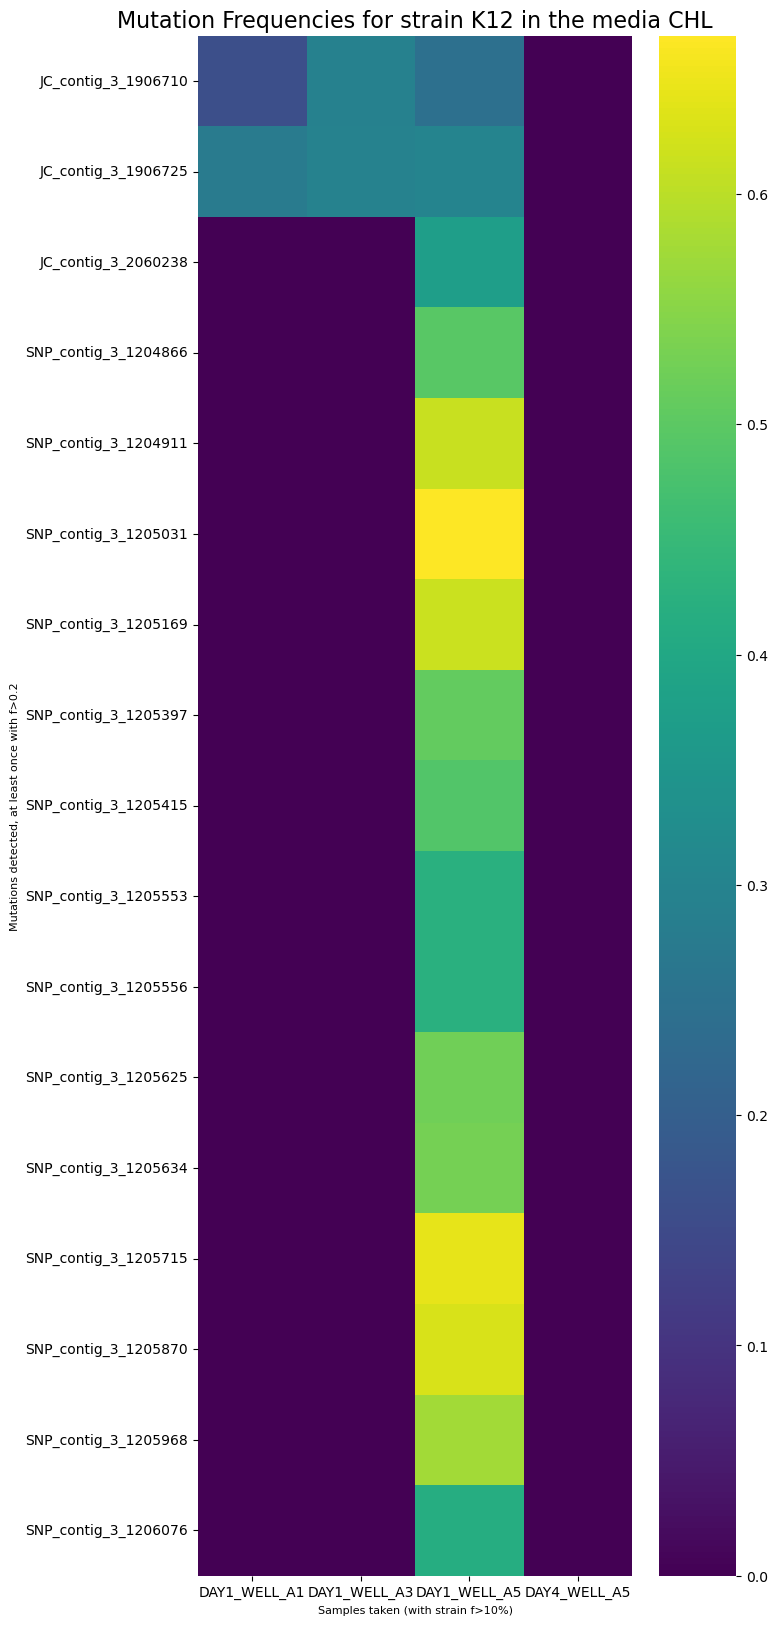

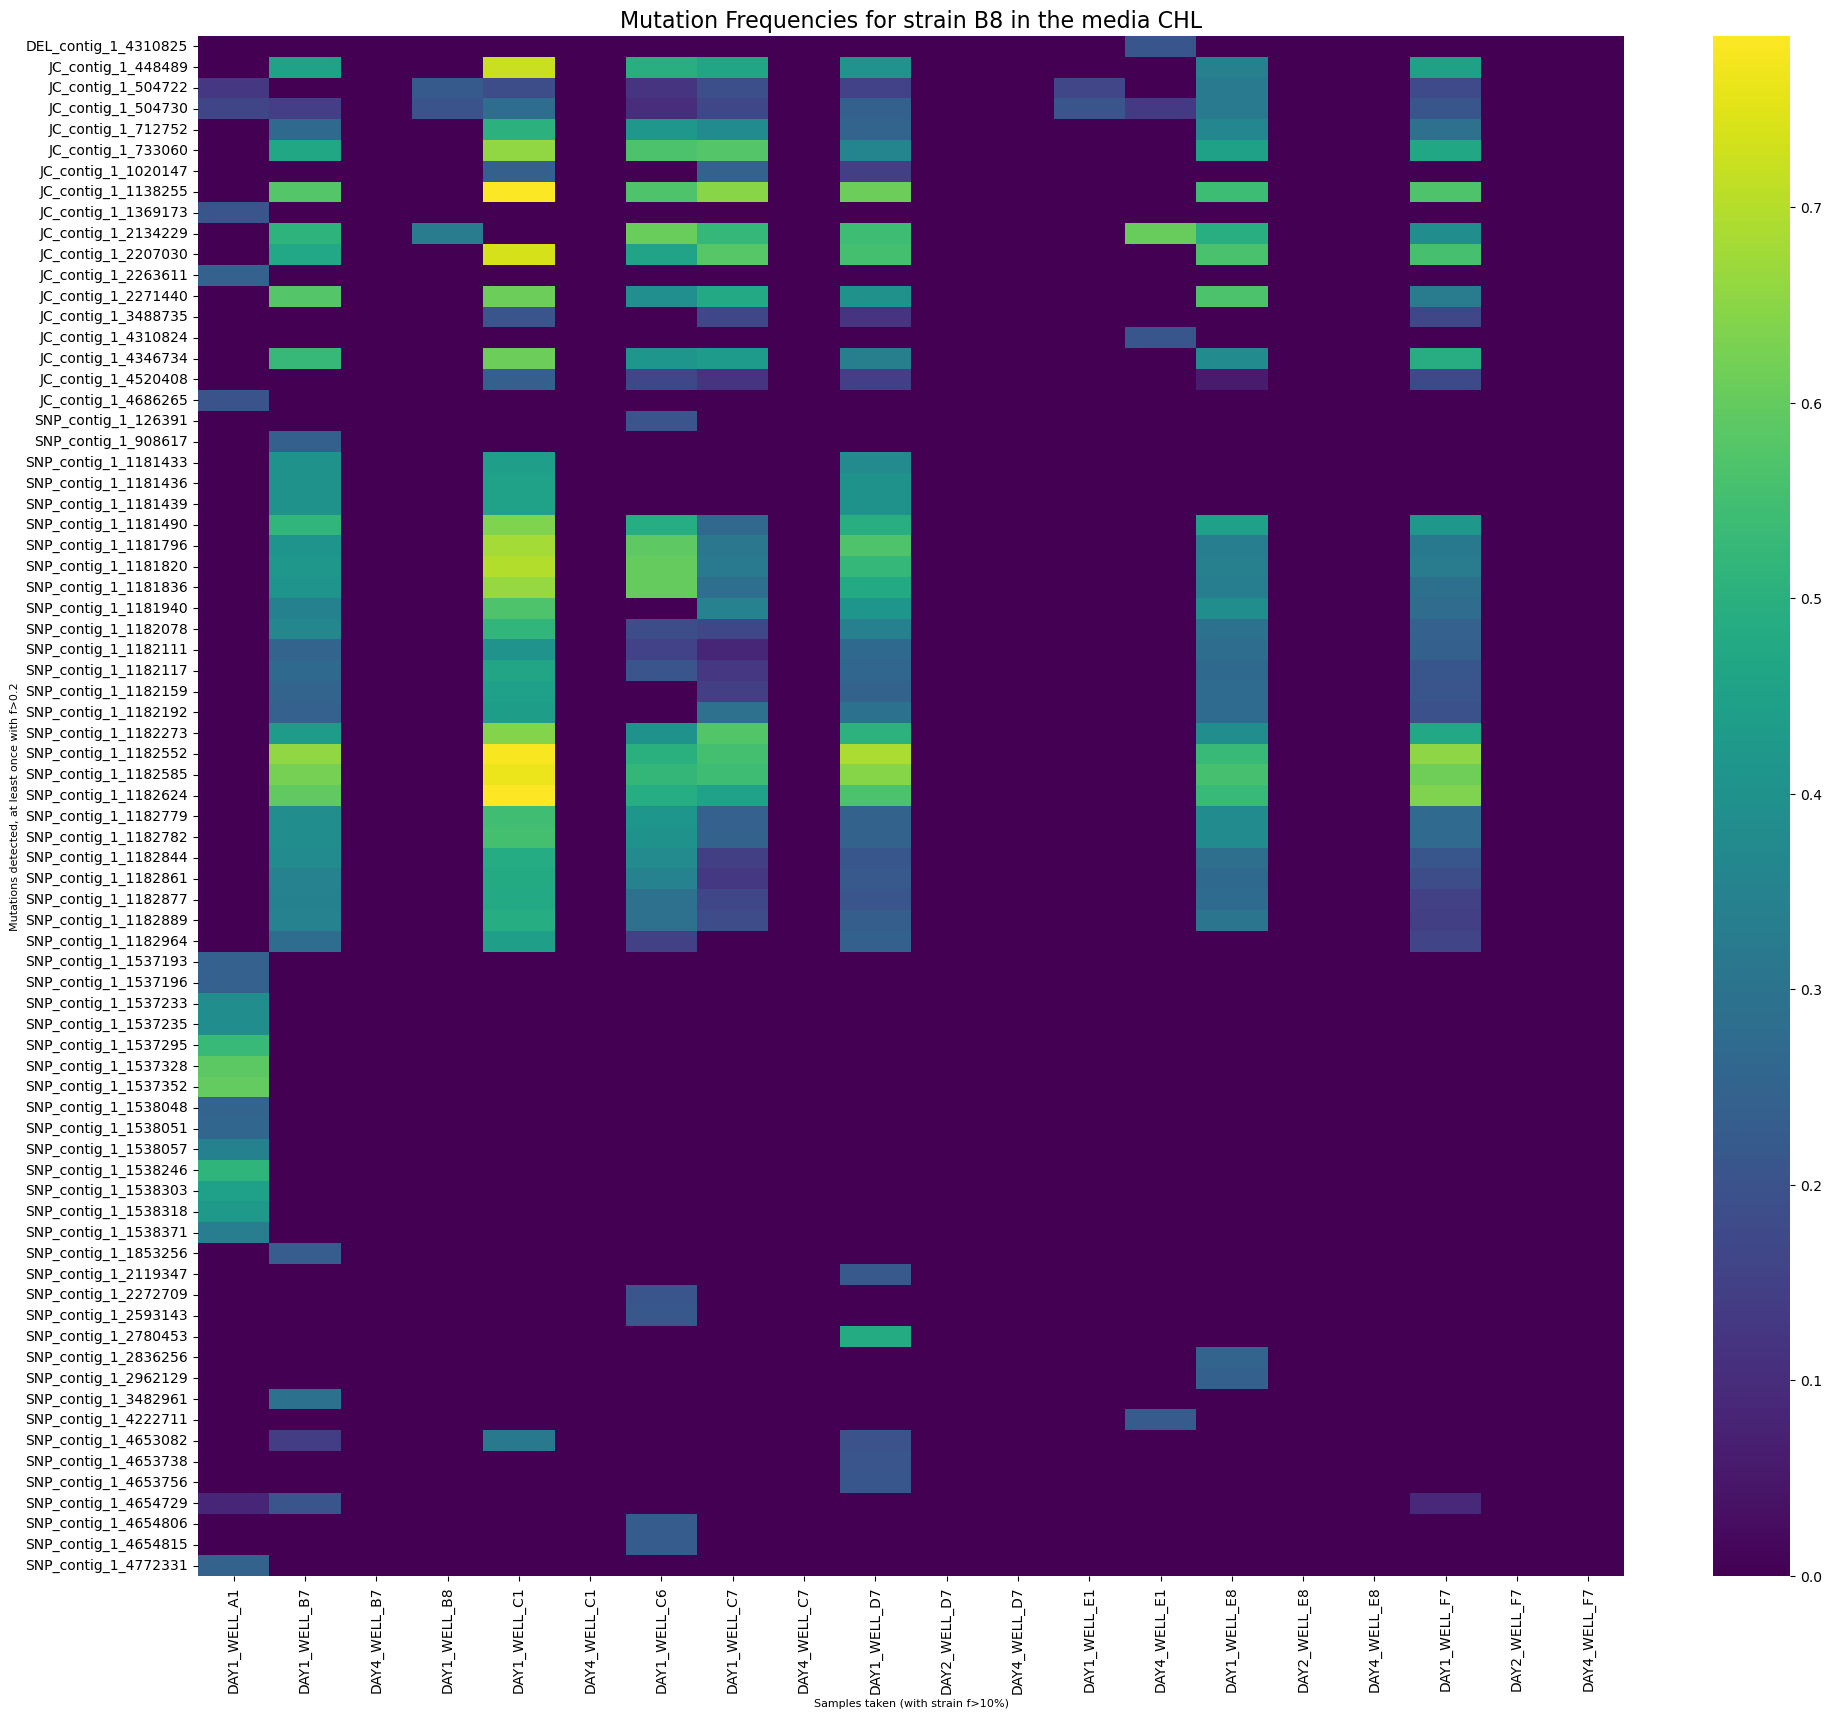

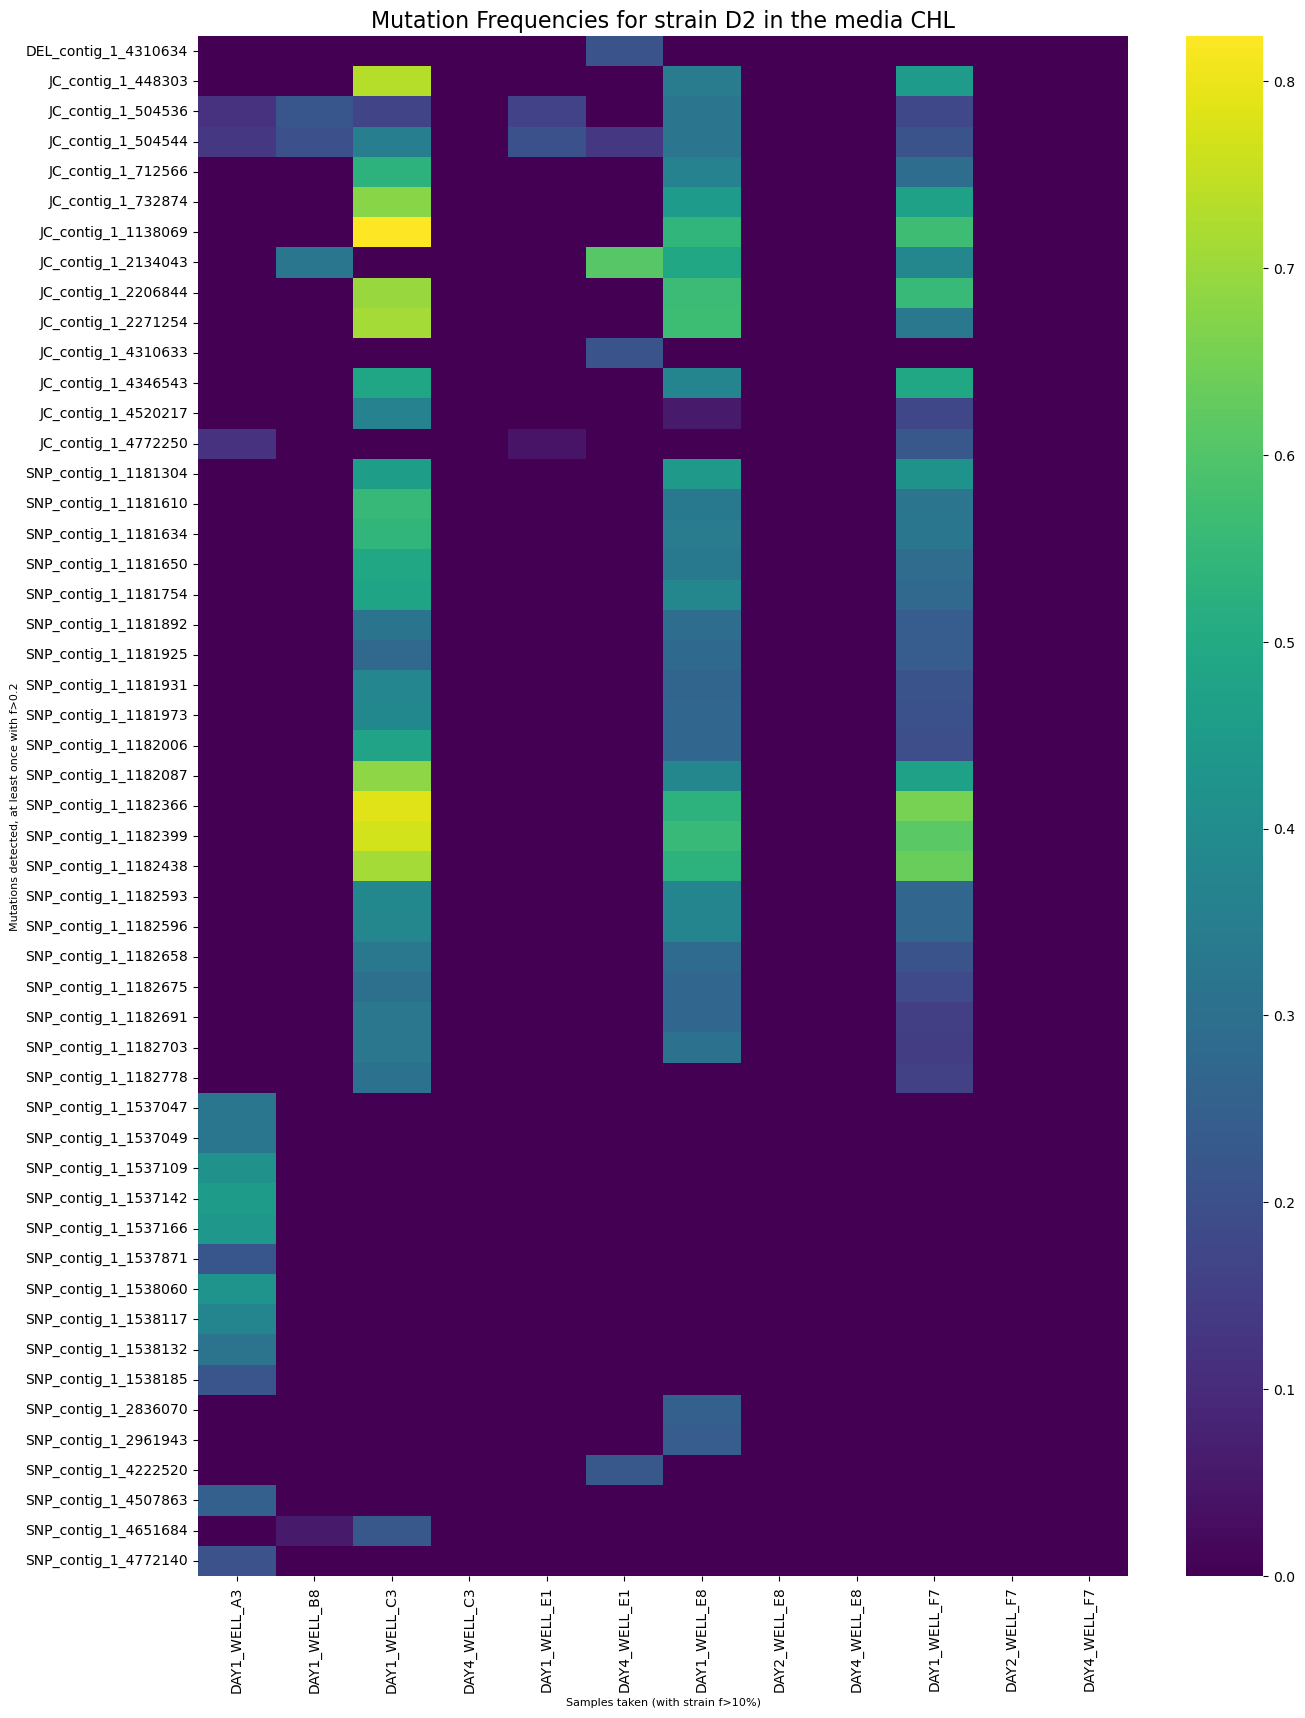

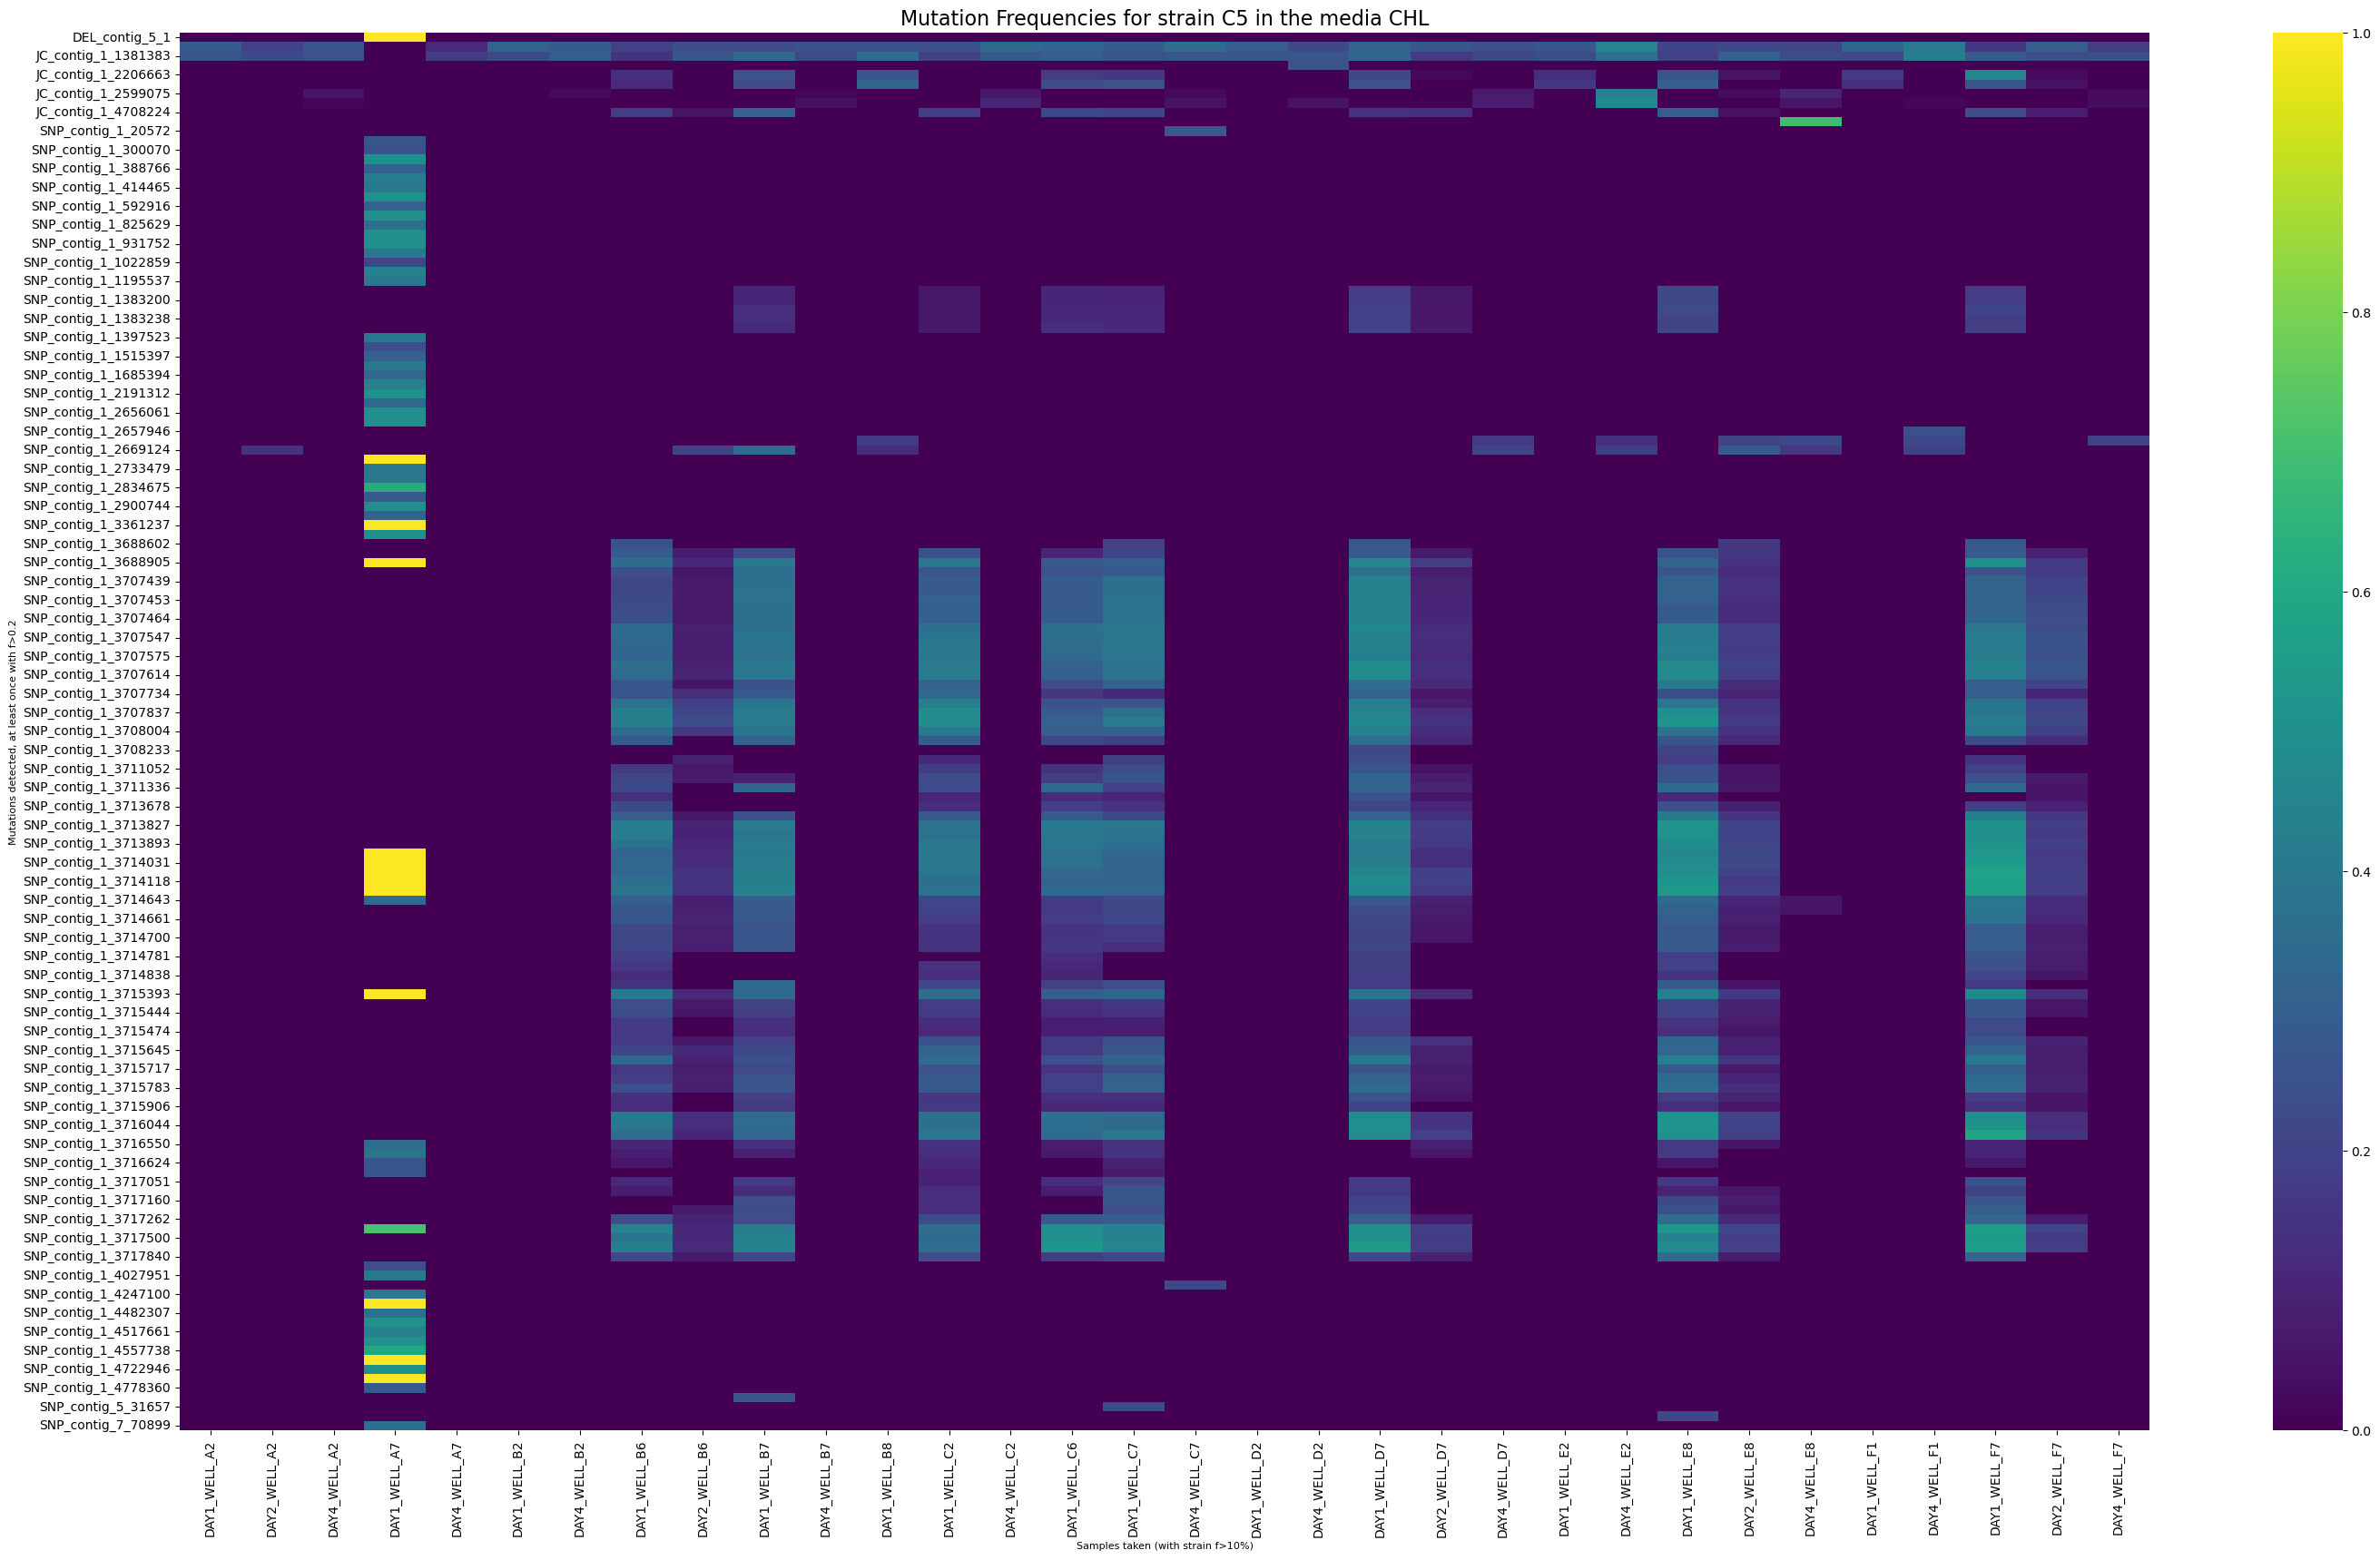

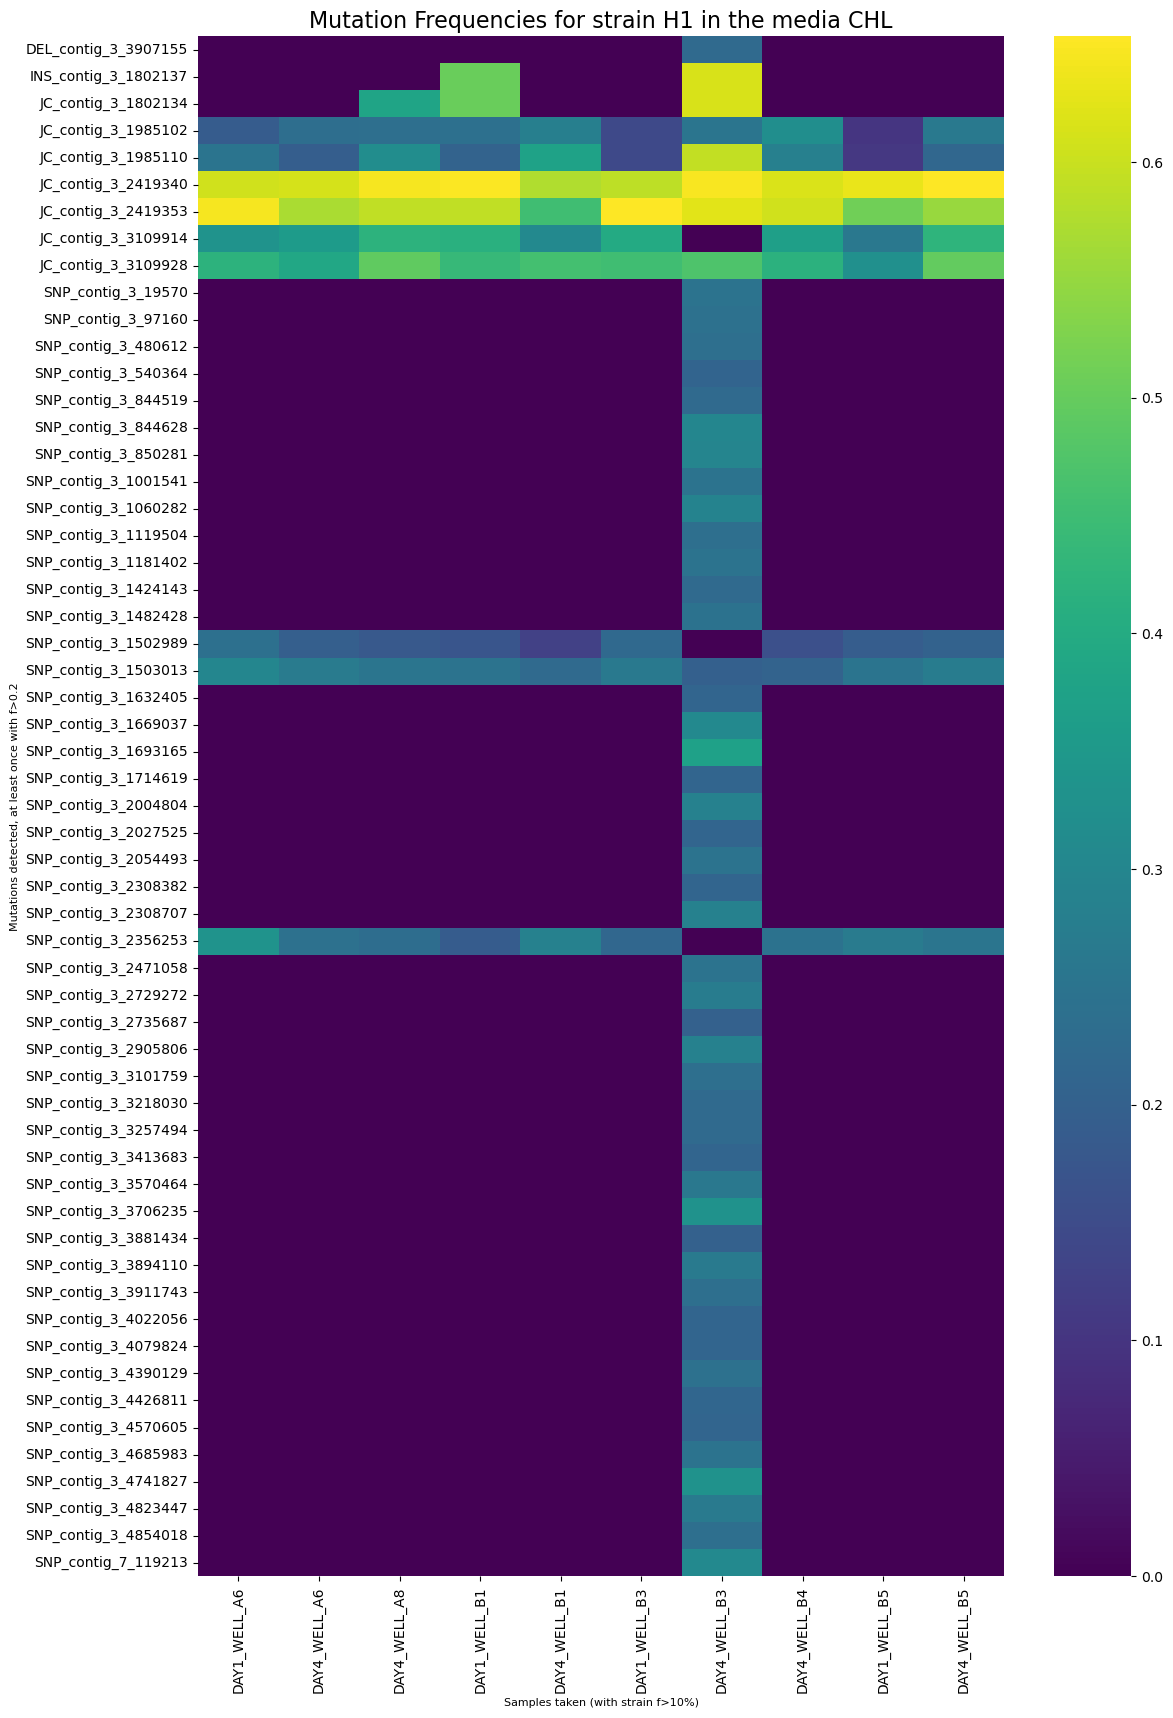

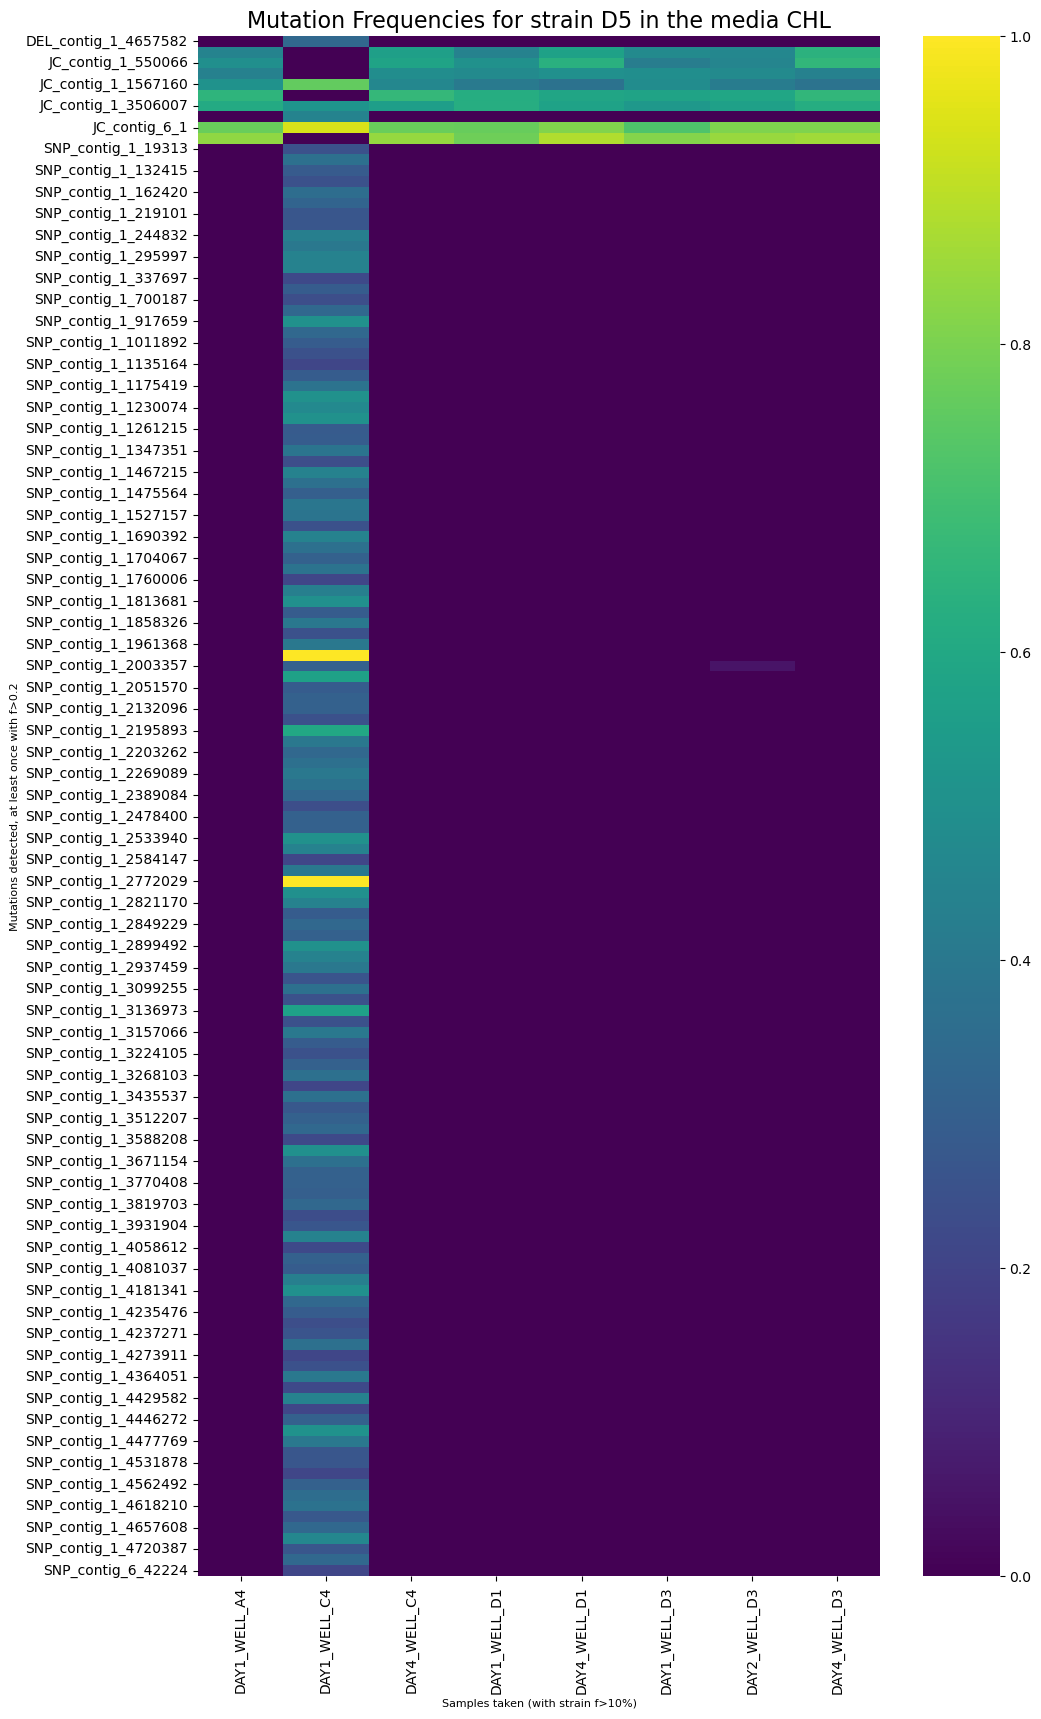

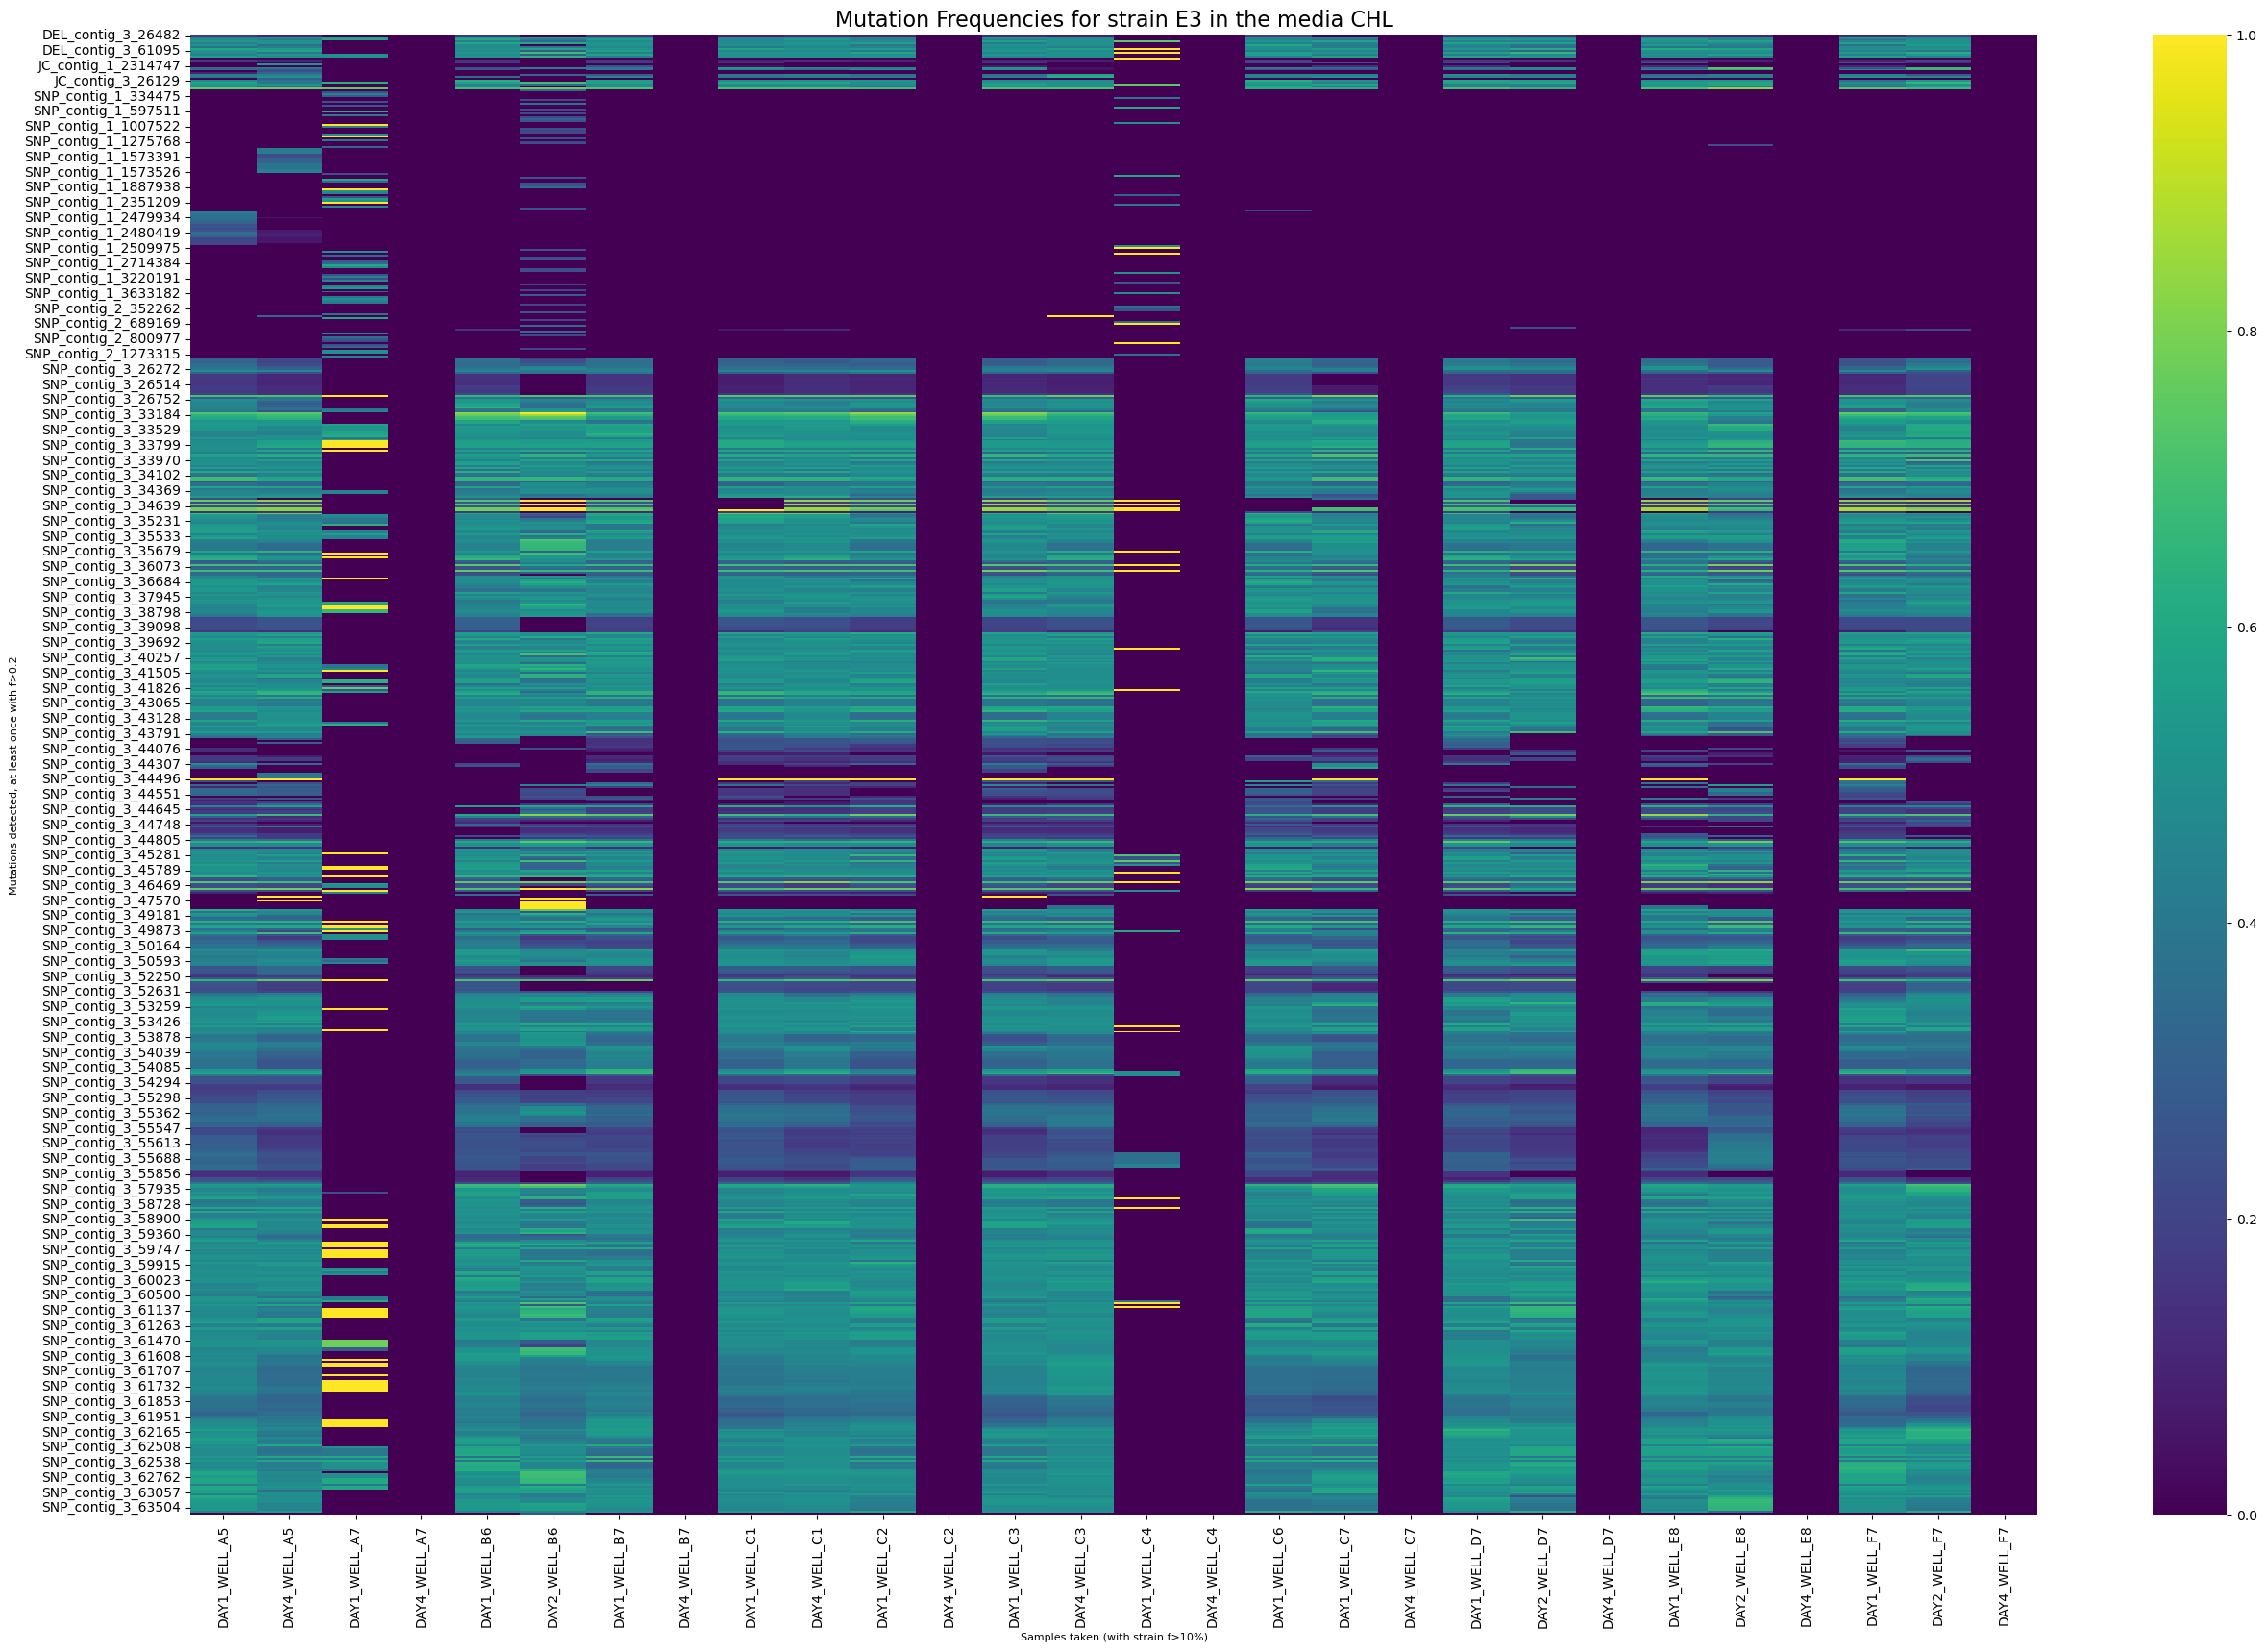

In [20]:
#CREATING THE HEATMAPS

for strain in all_strains:
    df_to_plot = dict_tot[strain]
    freq_matrix = df_to_plot.iloc[:,3:].apply(pd.to_numeric, errors='coerce').fillna(0.0)
    y_labels = df_to_plot['evidence']+'_'+df_to_plot['contig'].str.rstrip('_pilon')+'_'+df_to_plot['start'].astype(str)
    freq_matrix.index = y_labels
    if len(freq_matrix)<200:
        ysize = len((freq_matrix)/30)
    else:
        ysize = 200
    fig, ax = plt.subplots(figsize=(len(df_to_plot.iloc[0]), 20
                                   ))
    sns.heatmap(freq_matrix, cmap = 'viridis', cbar = True, annot = False, ax = ax)
    ax.set_title("Mutation Frequencies for strain "+strain+" in the media "+growth_media, fontsize=16)
    ax.set_xlabel('Samples taken (with strain f>10%)', fontsize = 8)
    ax.set_ylabel('Mutations detected, at least once with f>'+str(mutations_freq_cutoff), fontsize = 8)
    
    
